<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/autoencoder_to_perform_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2727 - val_loss: 0.2204
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1913 - val_loss: 0.1731
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1675 - val_loss: 0.1614
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1585 - val_loss: 0.1546
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1521 - val_loss: 0.1498
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1477 - val_loss: 0.1452
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1438 - val_loss: 0.1416
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1408 - val_loss: 0.1389
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1383 - val_loss: 0.1366
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1360 - val_loss: 0.1350
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


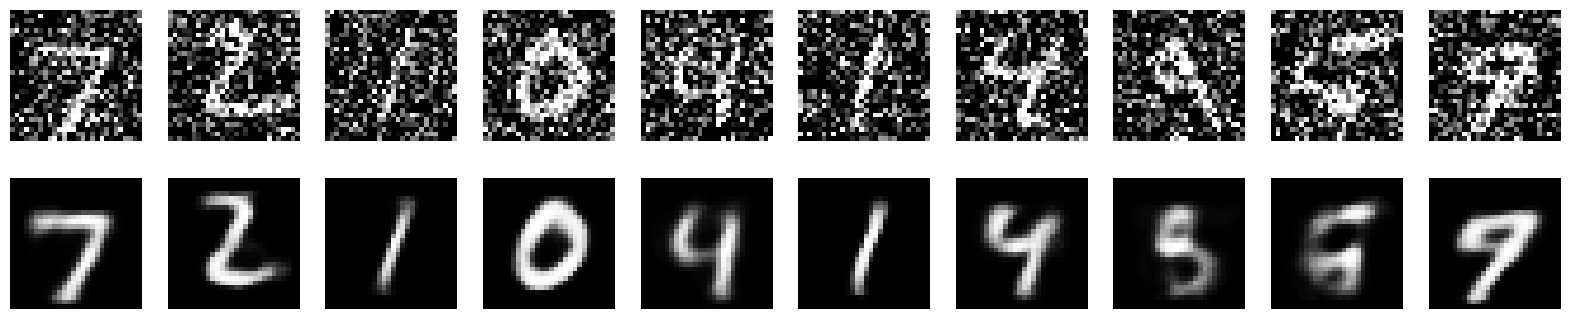

In [1]:
############
#
# Denoising Autoencoder
#
###########

### Import packages
import tensorflow as tf             # used to build and train the neural network
from tensorflow.keras import layers # helps create neural network layers
from tensorflow.keras import models # used to connect layers into a model
import matplotlib.pyplot as plt     # used to display images

### Load MNIST dataset
# The MNIST dataset contains images of handwritten digits (0–9).
# x_train contains training images.
# x_test contains testing images.
# We ignore the labels (_) because the autoencoder only needs images.

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

### Normalize pixel values
# Image pixels normally range from 0 to 255.
# Dividing by 255 converts them to values between 0 and 1.
# This makes training easier and faster for the neural network.

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

### Add noise to images
# Here we intentionally add random noise to the images.
# The goal of a Denoising Autoencoder is to learn how to remove this noise.

import numpy as np

noise_factor = 0.5   # controls how much noise is added

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Ensure pixel values stay within the valid range (0 to 1)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

### Flatten images (28x28 → 784)
# Each image has size 28 × 28 pixels.
# Neural networks usually work with 1-dimensional vectors.
# So we convert each image into a vector of 784 values.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), 784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), 784))

### Encoder
# The encoder compresses the noisy image into a smaller representation.
# Input layer receives 784 pixel values.
# Then the network gradually reduces the size of the data.

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)   # reduce size
encoded = layers.Dense(64, activation='relu')(encoded)      # further compression
encoded = layers.Dense(32, activation='relu')(encoded)      # bottleneck layer

# The bottleneck layer stores the most important information about the image.

### Decoder
# The decoder rebuilds the clean image from the compressed representation.
# The network gradually increases the size back to 784 pixels.

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# The final layer outputs 784 values representing the reconstructed image.

### Denoising Autoencoder model
# This connects the encoder and decoder together.
# Flow: Noisy Image → Encoder → Bottleneck → Decoder → Clean Image

autoencoder = models.Model(input_img, decoded)

### Compile model
# The optimizer helps the model learn better weights.
# The loss function measures the difference between original clean images and reconstructed images.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train model
# Important idea of denoising autoencoder:
# Input  = noisy images
# Output = clean images

history = autoencoder.fit(
    x_train_noisy, x_train,      # noisy input → clean target
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

### Reconstruct images
# The trained model now tries to remove noise from the test images.

decoded_imgs = autoencoder.predict(x_test_noisy)

### Plot noisy vs cleaned images
# First row  → noisy images
# Second row → cleaned images predicted by the model

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    # Cleaned Image (Model Output)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()